# EDA: `train_word_transcripts.jsonl`

This notebook performs an extensive exploratory data analysis (EDA) of competition labels in `data/train_word_transcripts.jsonl`.

It covers:
- dataset shape and schema checks
- data quality and duplicate diagnostics
- label/text distributions
- duration and file-size behavior
- child/session-level coverage
- token, n-gram, and lexical diversity analysis
- outlier surfacing for manual review

In [11]:
from pathlib import Path
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

DATA_PATH = Path("/home/lukasz/chilren-recognition-speech-lucas/childrens-speech-recognition-runtime/data/train_word_transcripts.jsonl")
print(Path.cwd())
assert DATA_PATH.exists(), f"Missing file: {DATA_PATH}"
print(f"Using file: {DATA_PATH.resolve()}")

/home/lukasz/chilren-recognition-speech-lucas/childrens-speech-recognition-runtime/notebooks
Using file: /home/lukasz/chilren-recognition-speech-lucas/childrens-speech-recognition-runtime/data/train_word_transcripts.jsonl


In [12]:
# Load JSONL
rows = []
with DATA_PATH.open() as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
df.head(3)

Rows: 95,572
Columns: 9


,utterance_id,child_id,session_id,audio_path,audio_duration_sec,age_bucket,md5_hash,filesize_bytes,orthographic_text
0,U_00003c3ae1c35c6f,C_c74bfde2cca8d5da,S_7d821c3e4d3bc616,audio/U_00003c3ae1c35c6f.flac,1.920,8-11,9214be45ba2928dd57384f3c7ee54236,30672,hm
1,U_00003db24218ffe4,C_c74bfde2cca8d5da,S_e6103ab3a4538d71,audio/U_00003db24218ffe4.flac,12.737,8-11,fe761bb3d034530ef05163c7ad98ec3e,180942,yeah its pouring the water on the screen but t...
2,U_0001a0d0a3b4d816,C_4d0e1c16566d65a2,S_179057c3c3ccdecf,audio/U_0001a0d0a3b4d816.flac,11.556,8-11,b05073e65a98368fccbe777b5ab35e02,208352,it got water and sunlight but the plant did di...


In [14]:
# Schema and type checks
expected_cols = [
    "utterance_id", "child_id", "session_id", "audio_path", "audio_duration_sec",
    "age_bucket", "md5_hash", "filesize_bytes", "orthographic_text"
]

print("Missing expected columns:", sorted(set(expected_cols) - set(df.columns)))
print("Unexpected columns:", sorted(set(df.columns) - set(expected_cols)))
print()
print(df.dtypes)
print()
print(df.describe(include="all").T)

Missing expected columns: []
Unexpected columns: []

utterance_id              str
child_id                  str
session_id                str
audio_path                str
audio_duration_sec    float64
age_bucket                str
md5_hash                  str
filesize_bytes          int64
orthographic_text         str
dtype: object

                      count unique                               top   freq  \
utterance_id          95572  95572                U_00003c3ae1c35c6f      1   
child_id              95572   2175                C_63baf19fc3f58441    546   
session_id            95572   5197                S_be0af0d94e7dde34    167   
audio_path            95572  95572     audio/U_00003c3ae1c35c6f.flac      1   
audio_duration_sec  95572.0    NaN                               NaN    NaN   
age_bucket            95572      3                              8-11  73970   
md5_hash              95572  95555  1cc1c211ae9ca71eae59549a229581e5      2   
filesize_bytes      95572.0   

In [15]:
# Missing values and blank text diagnostics
missing_summary = df.isna().sum().to_frame("missing_count")
missing_summary["missing_pct"] = 100 * missing_summary["missing_count"] / len(df)
missing_summary.sort_values("missing_count", ascending=False)


,missing_count,missing_pct
utterance_id,0,0.0
child_id,0,0.0
session_id,0,0.0
audio_path,0,0.0
audio_duration_sec,0,0.0
age_bucket,0,0.0
md5_hash,0,0.0
filesize_bytes,0,0.0
orthographic_text,0,0.0


In [16]:
blank_text_mask = df["orthographic_text"].astype(str).str.strip().eq("")
print(f"Blank text rows: {blank_text_mask.sum():,} ({100*blank_text_mask.mean():.3f}%)")

non_ascii_mask = ~df["orthographic_text"].fillna("").str.match(r"^[\x00-\x7F]*$")
print(f"Rows with non-ASCII chars in text: {non_ascii_mask.sum():,}")


Blank text rows: 0 (0.000%)
Rows with non-ASCII chars in text: 1


In [17]:
# Uniqueness and duplicate checks
id_uniqueness = {
    "utterance_id_nunique": df["utterance_id"].nunique(),
    "child_id_nunique": df["child_id"].nunique(),
    "session_id_nunique": df["session_id"].nunique(),
    "md5_hash_nunique": df["md5_hash"].nunique(),
    "audio_path_nunique": df["audio_path"].nunique(),
}
print(id_uniqueness)

print("\nDuplicate utterance_id rows:", int(df.duplicated(subset=["utterance_id"]).sum()))
print("Duplicate audio_path rows:", int(df.duplicated(subset=["audio_path"]).sum()))
print("Duplicate md5_hash rows:", int(df.duplicated(subset=["md5_hash"]).sum()))
print("Exact duplicate full rows:", int(df.duplicated().sum()))


{'utterance_id_nunique': 95572, 'child_id_nunique': 2175, 'session_id_nunique': 5197, 'md5_hash_nunique': 95555, 'audio_path_nunique': 95572}

Duplicate utterance_id rows: 0
Duplicate audio_path rows: 0
Duplicate md5_hash rows: 17
Exact duplicate full rows: 0


,count,pct
age_bucket,,
8-11,73970,77.40
5-7,11490,12.02
3-4,10112,10.58


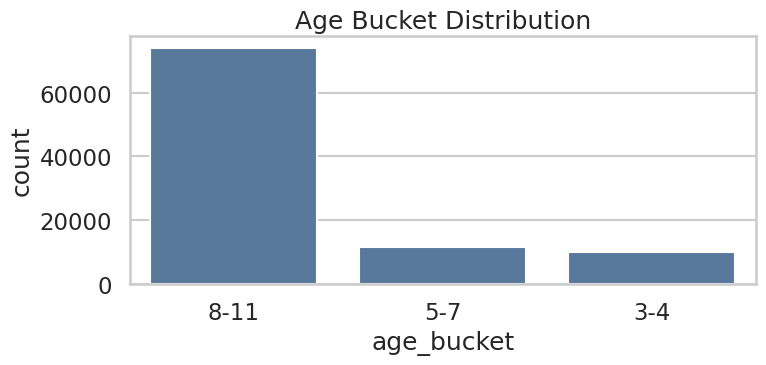

In [18]:
# Age bucket distribution
age_counts = df["age_bucket"].value_counts(dropna=False)
age_pct = (100 * age_counts / len(df)).round(2)
age_dist = pd.DataFrame({"count": age_counts, "pct": age_pct})
display(age_dist)

plt.figure(figsize=(8, 4))
sns.barplot(x=age_counts.index, y=age_counts.values, color="#4C78A8")
plt.title("Age Bucket Distribution")
plt.xlabel("age_bucket")
plt.ylabel("count")
plt.tight_layout()
plt.show()

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
audio_duration_sec,95572.0,6.982456,9.275244,0.079,0.428,0.734,1.78,4.086,9.054,22.82935,38.20909,1348.69
filesize_bytes,95572.0,137248.424968,147164.186969,9941.000,15132.970,21170.550,48049.25,94003.500,174619.250,402865.00000,671529.62000,14976281.00


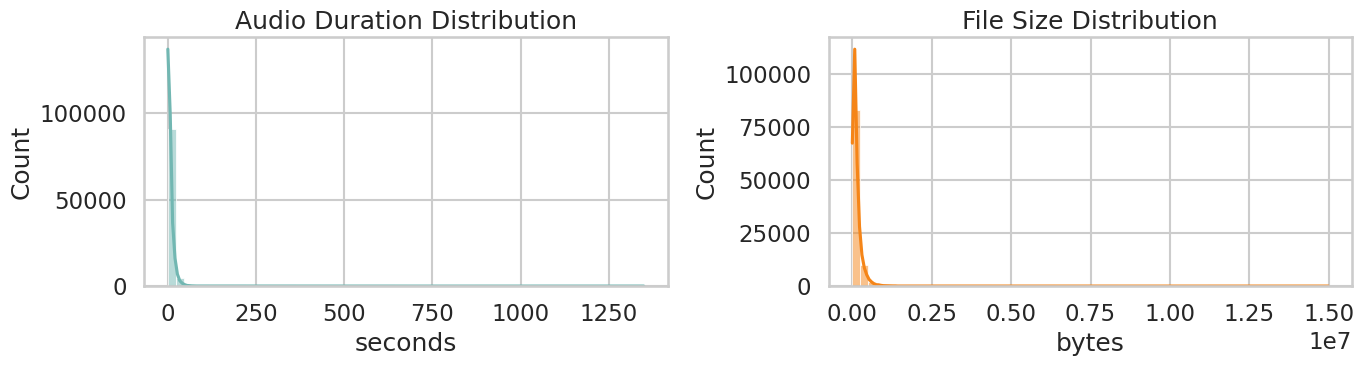

In [20]:
# Numeric distribution diagnostics
num_cols = ["audio_duration_sec", "filesize_bytes"]

display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["audio_duration_sec"], bins=60, kde=True, ax=axes[0], color="#72B7B2")
axes[0].set_title("Audio Duration Distribution")
axes[0].set_xlabel("seconds")

sns.histplot(df["filesize_bytes"], bins=60, kde=True, ax=axes[1], color="#F58518")
axes[1].set_title("File Size Distribution")
axes[1].set_xlabel("bytes")
plt.tight_layout()
plt.show()

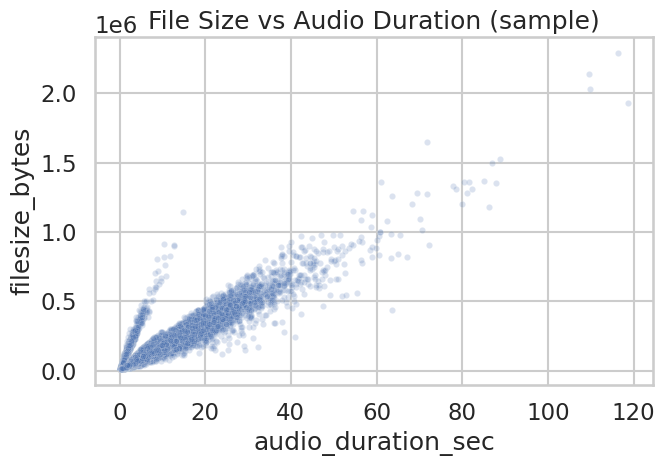

Pearson correlation (duration, filesize): 0.9315


In [21]:
# Duration-size relationship
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df.sample(min(20000, len(df)), random_state=42),
    x="audio_duration_sec", y="filesize_bytes", alpha=0.2, s=20
)
plt.title("File Size vs Audio Duration (sample)")
plt.tight_layout()
plt.show()

corr = df[["audio_duration_sec", "filesize_bytes"]].corr().iloc[0, 1]
print(f"Pearson correlation (duration, filesize): {corr:.4f}")

In [22]:
# Build text-derived features
text = df["orthographic_text"].fillna("").astype(str)

def tokenize(s: str):
    s = s.lower()
    s = re.sub(r"[^a-z0-9' ]+", " ", s)
    toks = [t for t in s.split() if t]
    return toks

df["char_count"] = text.str.len()
df["word_count"] = text.apply(lambda s: len(tokenize(s)))
df["avg_word_len"] = text.apply(lambda s: np.mean([len(t) for t in tokenize(s)]) if tokenize(s) else 0.0)
df["words_per_second"] = df["word_count"] / df["audio_duration_sec"].replace(0, np.nan)

feature_cols = ["char_count", "word_count", "avg_word_len", "words_per_second"]
display(df[feature_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)


,count,mean,std,min,1%,5%,50%,95%,99%,max
char_count,95572.0,66.449117,85.388705,1.000000,2.00000,3.000000,38.000000,232.000000,398.000000,2048.000000
word_count,95572.0,13.493691,17.456904,1.000000,1.00000,1.000000,8.000000,47.000000,82.000000,455.000000
avg_word_len,95572.0,4.114024,1.081691,1.000000,2.00000,3.000000,4.000000,6.000000,8.000000,16.000000
words_per_second,95572.0,1.860028,0.931472,0.000741,0.26178,0.502513,1.850428,3.243054,4.093567,49.036778


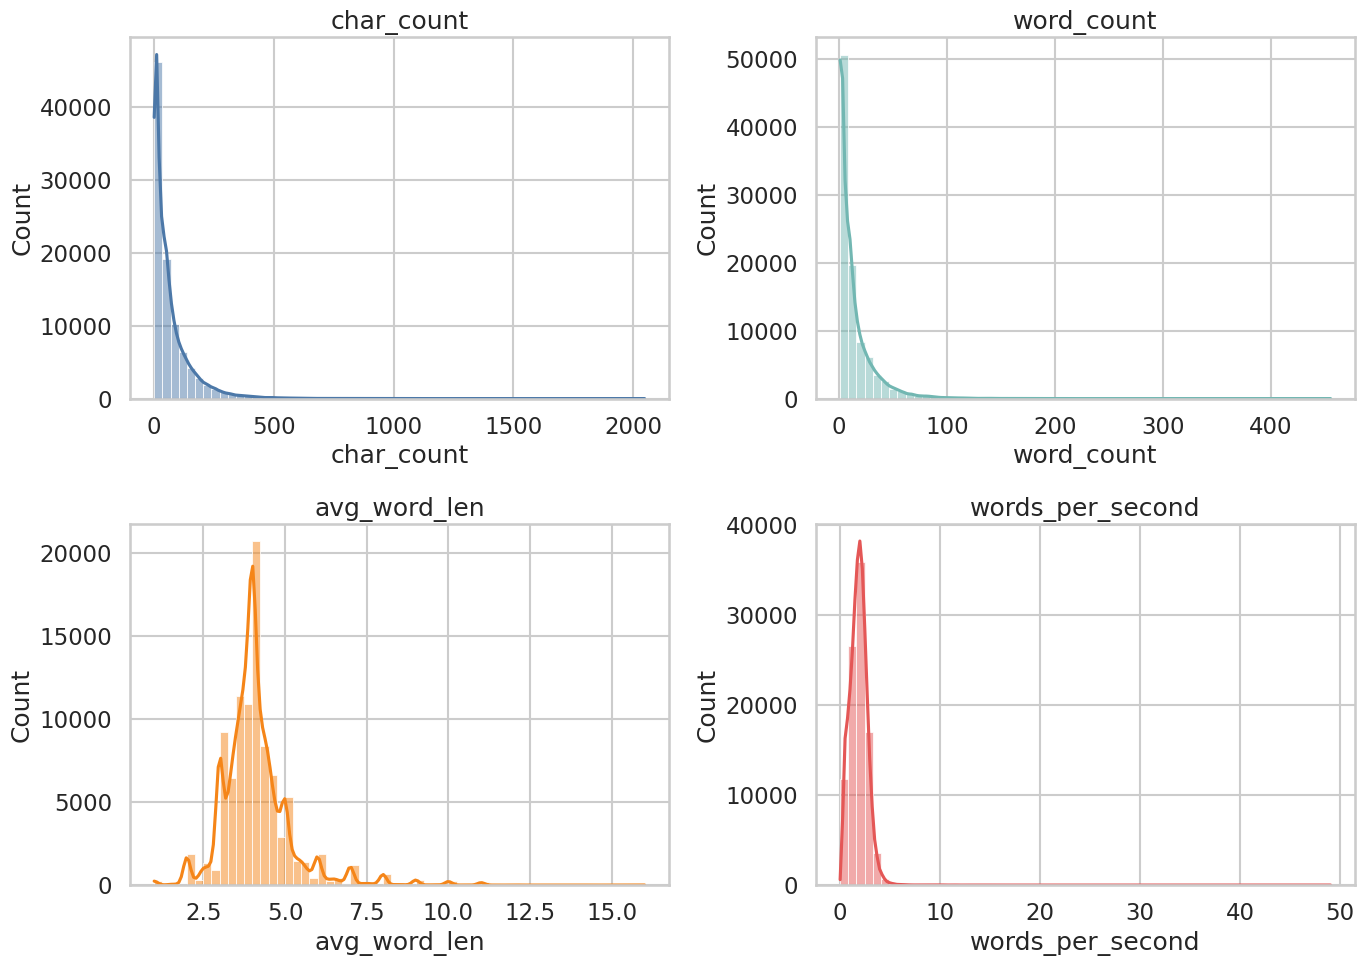

In [23]:
# Text feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_cols = ["char_count", "word_count", "avg_word_len", "words_per_second"]
colors = ["#4C78A8", "#72B7B2", "#F58518", "#E45756"]

for ax, col, c in zip(axes.ravel(), plot_cols, colors):
    sns.histplot(df[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=60, kde=True, ax=ax, color=c)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Total tokens: 1,289,619
Unique tokens (vocab size): 10,732
Type-token ratio: 0.00832


,token,count
0,the,95493
1,and,54052
2,it,43652
3,a,29749
4,to,26391
5,is,21910
6,that,19383
7,you,19010
8,um,18227
9,like,17740


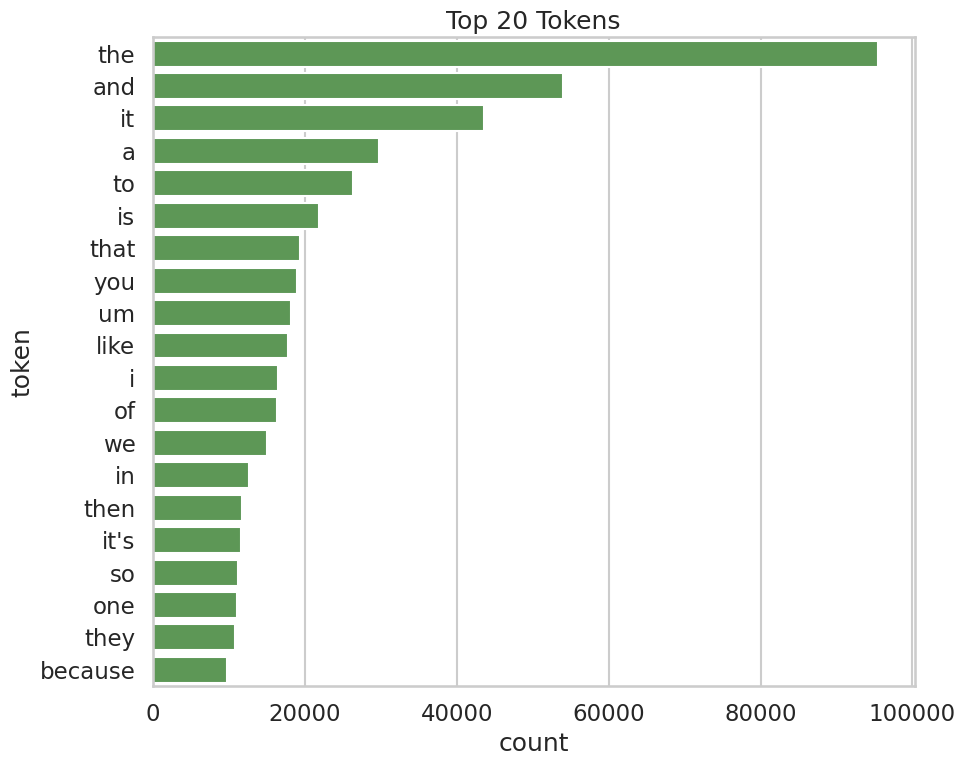

In [24]:
# Top tokens and lexical diversity
all_tokens = []
for s in text:
    all_tokens.extend(tokenize(s))

token_counts = Counter(all_tokens)
print(f"Total tokens: {len(all_tokens):,}")
print(f"Unique tokens (vocab size): {len(token_counts):,}")
print(f"Type-token ratio: {len(token_counts)/max(len(all_tokens),1):.5f}")

top_tokens = pd.DataFrame(token_counts.most_common(50), columns=["token", "count"])
display(top_tokens.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(data=top_tokens.head(20), y="token", x="count", color="#54A24B")
plt.title("Top 20 Tokens")
plt.tight_layout()
plt.show()

,bigram,count
0,and then,7845
1,and the,6761
2,to the,5591
3,of the,4963
4,in the,4193
5,on the,3696
6,and it,3266
7,light bulb,3241
8,the light,3088
9,i think,3054


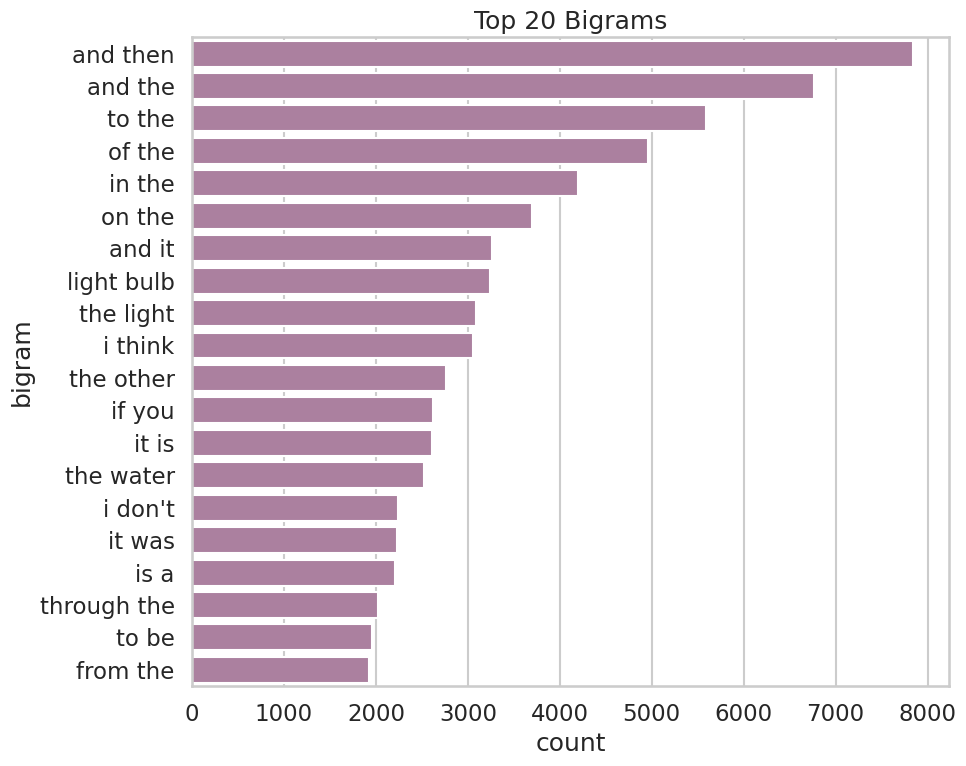

In [ ]:
# Top bigrams
bigram_counts = Counter()
for s in text:
    toks = tokenize(s)
    bigram_counts.update(zip(toks, toks[1:]))

top_bigrams = pd.DataFrame(
    [(f"{a} {b}", c) for (a, b), c in bigram_counts.most_common(30)],
    columns=["bigram", "count"]
)
display(top_bigrams.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(data=top_bigrams.head(20), y="bigram", x="count", color="#B279A2")
plt.title("Top 20 Bigrams")
plt.tight_layout()
plt.show()
plt.show()

Child-level summary


,count,mean,std,min,50%,90%,99%,max
n_utterances,2175.0,43.941149,82.814266,1.00,9.000000,152.000000,362.780000,546.000000
total_duration_sec,2175.0,306.817131,669.695035,0.96,31.880000,1053.705800,3230.031760,5471.200000
mean_words,2175.0,8.656007,7.426534,1.00,7.746667,17.159195,35.003407,61.821782


Session-level summary


,count,mean,std,min,50%,90%,99%,max
n_utterances,5197.0,18.389840,19.373681,1.000,13.000,41.0000,91.00000,167.000
total_duration_sec,5197.0,128.406246,151.991859,0.935,55.727,343.0446,610.21832,1922.589
n_children,5197.0,1.000000,0.000000,1.000,1.000,1.0000,1.00000,1.000


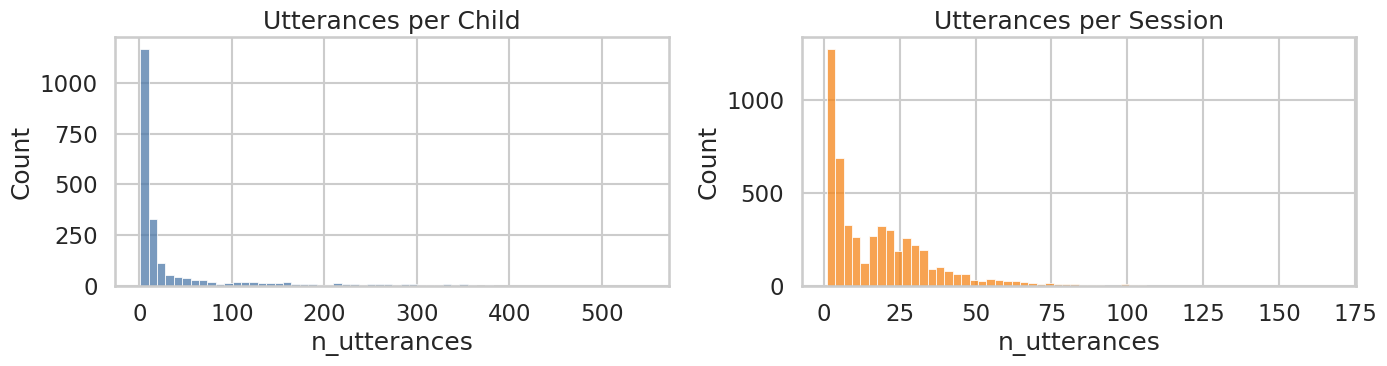

In [26]:
# Per-child and per-session coverage
child_stats = df.groupby("child_id").agg(
    n_utterances=("utterance_id", "count"),
    total_duration_sec=("audio_duration_sec", "sum"),
    mean_words=("word_count", "mean")
).sort_values("n_utterances", ascending=False)

session_stats = df.groupby("session_id").agg(
    n_utterances=("utterance_id", "count"),
    total_duration_sec=("audio_duration_sec", "sum"),
    n_children=("child_id", "nunique")
).sort_values("n_utterances", ascending=False)

print("Child-level summary")
display(child_stats.describe(percentiles=[0.5, 0.9, 0.99]).T)
print("Session-level summary")
display(session_stats.describe(percentiles=[0.5, 0.9, 0.99]).T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(child_stats["n_utterances"], bins=60, ax=axes[0], color="#4C78A8")
axes[0].set_title("Utterances per Child")

sns.histplot(session_stats["n_utterances"], bins=60, ax=axes[1], color="#F58518")
axes[1].set_title("Utterances per Session")
plt.tight_layout()
plt.show()

,n,duration_mean,words_mean,wps_mean
age_bucket,,,,
8-11,73970,8.270541,16.324794,1.988889
5-7,11490,3.365662,4.510966,1.131188
3-4,10112,1.669691,2.990803,1.745562


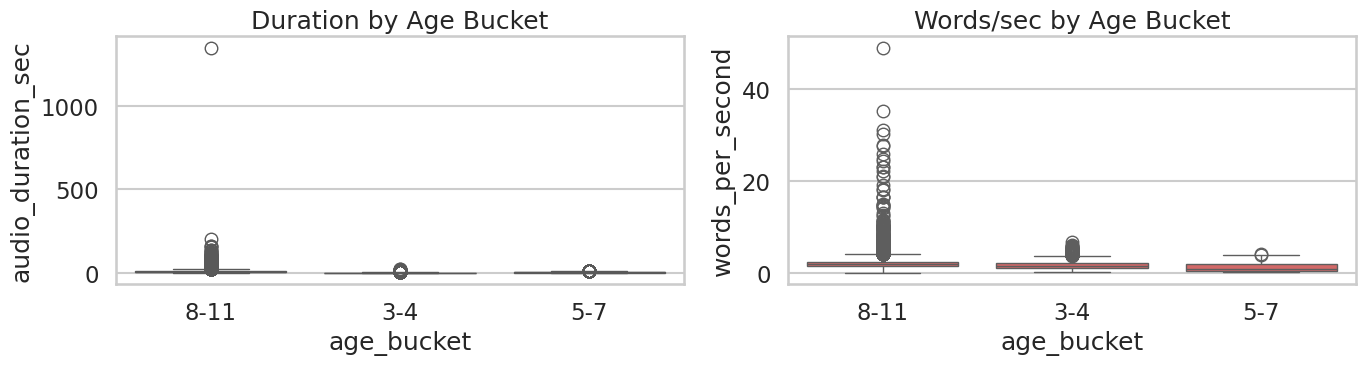

In [27]:
# Age bucket comparison of speaking rate and duration
agg = df.groupby("age_bucket").agg(
    n=("utterance_id", "count"),
    duration_mean=("audio_duration_sec", "mean"),
    words_mean=("word_count", "mean"),
    wps_mean=("words_per_second", "mean")
).sort_values("n", ascending=False)

display(agg)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x="age_bucket", y="audio_duration_sec", ax=axes[0], color="#72B7B2")
axes[0].set_title("Duration by Age Bucket")

sns.boxplot(data=df.replace([np.inf, -np.inf], np.nan), x="age_bucket", y="words_per_second", ax=axes[1], color="#E45756")
axes[1].set_title("Words/sec by Age Bucket")
plt.tight_layout()
plt.show()

In [28]:
# Outlier surfacing for manual inspection
# Define conservative outliers using quantile thresholds
q = df[["audio_duration_sec", "word_count", "words_per_second", "filesize_bytes"]].quantile([0.01, 0.99])
q01, q99 = q.loc[0.01], q.loc[0.99]

outlier_mask = (
    (df["audio_duration_sec"] < q01["audio_duration_sec"]) |
    (df["audio_duration_sec"] > q99["audio_duration_sec"]) |
    (df["word_count"] < q01["word_count"]) |
    (df["word_count"] > q99["word_count"]) |
    (df["words_per_second"] < q01["words_per_second"]) |
    (df["words_per_second"] > q99["words_per_second"]) |
    (df["filesize_bytes"] < q01["filesize_bytes"]) |
    (df["filesize_bytes"] > q99["filesize_bytes"])
)

outliers = df.loc[outlier_mask, [
    "utterance_id", "child_id", "session_id", "age_bucket",
    "audio_duration_sec", "filesize_bytes", "word_count", "words_per_second", "orthographic_text"
]].copy()

print(f"Outlier candidates: {len(outliers):,} ({100*len(outliers)/len(df):.2f}%)")
outliers.head(20)


Outlier candidates: 4,487 (4.69%)


,utterance_id,child_id,session_id,age_bucket,audio_duration_sec,filesize_bytes,word_count,words_per_second,orthographic_text
14,U_000f24e359c06caf,C_e2676f2cc72877b4,S_5607c15821055988,5-7,4.080,96707,1,0.245098,slash
61,U_00287770c38a1d42,C_1128f2690d3b10d4,S_364c847e5de4c1e5,8-11,1.368,29763,7,5.116959,yeah oh yeah we made a cu
73,U_0035443b909d5f6d,C_0fbea0b5205dcf82,S_c24e5bafd82bd7ec,8-11,0.605,20117,3,4.958678,i don't know
74,U_003553aeccad3fd6,C_59940da87de5f402,S_c75640bc0cdd884b,8-11,90.319,1489592,185,2.048295,s things that we did with sponge we put the sp...
75,U_0035b4ac246f7a31,C_ae774cac66d6e717,S_2167acd9e93fa279,8-11,1.206,24551,5,4.145937,er wait a second um
147,U_006d8dc50673aa6f,C_f1509fdb7948bed1,S_dc610db7e49c4987,8-11,0.208,13152,1,4.807692,dif
170,U_007ed4c07e645a50,C_8e6661ba87cf2132,S_5ee9cf6064786516,8-11,64.141,1374144,119,1.855288,magnet stick to lots of lots of like cold thin...
171,U_007f04891c22caf9,C_38231c40656453c7,S_7ab49af43d0f25dc,8-11,0.471,13345,2,4.246285,n mmm
197,U_0091a49364b9a86d,C_001a98a366d4acd2,S_27f57673642be250,8-11,59.988,921126,115,1.917050,um well mmm our teacher played a trick on us a...
229,U_00a6aa0e3395b401,C_bb44003703919c45,S_d81eb178d79c6358,8-11,1.714,44994,8,4.667445,and then we did a response on it


In [29]:
# Optional: save key summary artifacts for downstream modeling notes
summary_dir = Path("statisitcs")
summary_dir.mkdir(parents=True, exist_ok=True)

age_dist.to_csv(summary_dir / "eda_age_distribution.csv")
child_stats.reset_index().to_csv(summary_dir / "eda_child_stats.csv", index=False)
session_stats.reset_index().to_csv(summary_dir / "eda_session_stats.csv", index=False)
top_tokens.to_csv(summary_dir / "eda_top_tokens.csv", index=False)
top_bigrams.to_csv(summary_dir / "eda_top_bigrams.csv", index=False)
outliers.to_csv(summary_dir / "eda_outlier_candidates.csv", index=False)

print(f"Saved EDA summaries to: {summary_dir.resolve()}")

Saved EDA summaries to: /home/lukasz/chilren-recognition-speech-lucas/childrens-speech-recognition-runtime/notebooks/statisitcs


## Next steps

Potential follow-up analyses:
- stratify train/validation splits by `child_id` and `age_bucket` to reduce leakage
- compare transcript complexity and speaking rate by child/session
- integrate acoustic-level stats from audio files to tie text labels to signal properties